In [14]:
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver

In [15]:
load_dotenv()

True

In [16]:
# Define the Hugging Face endpoint
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    # repo_id="openai/gpt-oss-120b",
    task="text-generation",
    max_new_tokens=2048,
)

# Define the model
model = ChatHuggingFace(llm=llm)

In [17]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str
    

In [18]:
def gen_joke(state: JokeState):

    prompt = f"Generate a funny joke on the given topic : {state['topic']}"
    response = model.invoke(prompt).content
    return {"joke": response}

def explain_joke(state: JokeState):

    prompt = f"Explain the joke : {state['joke']}"
    response = model.invoke(prompt).content
    return {"explanation": response}

In [19]:
# define the graph
graph = StateGraph(JokeState)

# add nodes to the graph
graph.add_node("generate_joke", gen_joke)
graph.add_node("explain_joke", explain_joke)

# add edges to the graph
graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explain_joke")
graph.add_edge("explain_joke", END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

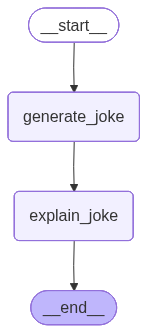

In [20]:
workflow

In [21]:
# define the config
config1 = {"configurable": {"thread_id" : "1"}}

# define the initial state
initial_state = {"topic": "programming"}

final_state = workflow.invoke(initial_state, config=config1)

In [22]:
final_state

{'topic': 'programming',
 'joke': "Why did the programmer quit his job?\n\nBecause he didn't get arrays!",
 'explanation': 'This is a play on words and a common joke in the programming world. The punchline "Because he didn\'t get arrays!" is a humorous twist because:\n\n1. **Arrays in Programming**: In computer science, arrays are a fundamental data structure used to store a collection of elements. Programmers often need to understand and work with arrays to manipulate and process data.\n\n2. **Pun and Misunderstanding**: The joke plays on the double meaning of "didn\'t get arrays." On one hand, it could mean the programmer didn\'t understand or couldn\'t work with arrays in code. On the other hand, "array" is also a word in English, and the punchline suggests that the programmer left his job because he misunderstood or was frustrated by something in his workplace, rather than a technical issue with arrays.\n\nSo, the humor comes from the contrast between the literal meaning of not und

In [23]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'programming', 'joke': "Why did the programmer quit his job?\n\nBecause he didn't get arrays!", 'explanation': 'This is a play on words and a common joke in the programming world. The punchline "Because he didn\'t get arrays!" is a humorous twist because:\n\n1. **Arrays in Programming**: In computer science, arrays are a fundamental data structure used to store a collection of elements. Programmers often need to understand and work with arrays to manipulate and process data.\n\n2. **Pun and Misunderstanding**: The joke plays on the double meaning of "didn\'t get arrays." On one hand, it could mean the programmer didn\'t understand or couldn\'t work with arrays in code. On the other hand, "array" is also a word in English, and the punchline suggests that the programmer left his job because he misunderstood or was frustrated by something in his workplace, rather than a technical issue with arrays.\n\nSo, the humor comes from the contrast between the literal

In [24]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'programming', 'joke': "Why did the programmer quit his job?\n\nBecause he didn't get arrays!", 'explanation': 'This is a play on words and a common joke in the programming world. The punchline "Because he didn\'t get arrays!" is a humorous twist because:\n\n1. **Arrays in Programming**: In computer science, arrays are a fundamental data structure used to store a collection of elements. Programmers often need to understand and work with arrays to manipulate and process data.\n\n2. **Pun and Misunderstanding**: The joke plays on the double meaning of "didn\'t get arrays." On one hand, it could mean the programmer didn\'t understand or couldn\'t work with arrays in code. On the other hand, "array" is also a word in English, and the punchline suggests that the programmer left his job because he misunderstood or was frustrated by something in his workplace, rather than a technical issue with arrays.\n\nSo, the humor comes from the contrast between the litera

In [25]:
config2 = {"configurable": {"thread_id" : "2"}}

workflow.invoke({"topic": "pizza"}, config=config2)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job as a golfer?\n\nBecause it wanted to get hole-in-one and stretch its toppings!',
 'explanation': 'This joke plays on several elements to create a humorous pun. Let\'s break it down:\n\n1. **Pun**: The word "hole-in-one" originally refers to a golf term, meaning a ball is hit to land directly in the hole in a single stroke. However, in the context of the pizza, the term is transformed to mean something different—getting a job and doing well at it, or achieving a desired position.\n\n2. **Wordplay**: The phrase "stretch its toppings" is another play on words. In a normal context, this could mean to spread or extend the toppings out. But when applied to a job as a golfer, this suggests the idea of performing well or excelling, as if the pizza were taking on a more human quality to achieve its goals.\n\n3. **Cultural Reference**: The joke alludes to the common phrase "stretch your legs" or "stretch out," which can mean to relax

In [26]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job as a golfer?\n\nBecause it wanted to get hole-in-one and stretch its toppings!', 'explanation': 'This joke plays on several elements to create a humorous pun. Let\'s break it down:\n\n1. **Pun**: The word "hole-in-one" originally refers to a golf term, meaning a ball is hit to land directly in the hole in a single stroke. However, in the context of the pizza, the term is transformed to mean something different—getting a job and doing well at it, or achieving a desired position.\n\n2. **Wordplay**: The phrase "stretch its toppings" is another play on words. In a normal context, this could mean to spread or extend the toppings out. But when applied to a job as a golfer, this suggests the idea of performing well or excelling, as if the pizza were taking on a more human quality to achieve its goals.\n\n3. **Cultural Reference**: The joke alludes to the common phrase "stretch your legs" or "stretch out," whic

In [28]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job as a golfer?\n\nBecause it wanted to get hole-in-one and stretch its toppings!', 'explanation': 'This joke plays on several elements to create a humorous pun. Let\'s break it down:\n\n1. **Pun**: The word "hole-in-one" originally refers to a golf term, meaning a ball is hit to land directly in the hole in a single stroke. However, in the context of the pizza, the term is transformed to mean something different—getting a job and doing well at it, or achieving a desired position.\n\n2. **Wordplay**: The phrase "stretch its toppings" is another play on words. In a normal context, this could mean to spread or extend the toppings out. But when applied to a job as a golfer, this suggests the idea of performing well or excelling, as if the pizza were taking on a more human quality to achieve its goals.\n\n3. **Cultural Reference**: The joke alludes to the common phrase "stretch your legs" or "stretch out," whi

### Time Travel

In [30]:
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f132970-6ef1-6f9f-8000-41a5f54b938a"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f132970-6ef1-6f9f-8000-41a5f54b938a'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-07T15:32:46.298102+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f132970-6eed-60d2-bfff-52baf6d5755d'}}, tasks=(PregelTask(id='1586254e-beb8-5bf0-3a61-047a61c3599e', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza apply for a job as a golfer?\n\nBecause it wanted to get hole-in-one and stretch its toppings!'}),), interrupts=())

In [31]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f132970-6ef1-6f9f-8000-41a5f54b938a"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor?\n\nBecause it was feeling a little slice-asy!',
 'explanation': 'This joke is a play on words and a pun. The joke uses the phrase "slice-asy," which is a combination of "slice" (as in a piece of pizza) and "anxiety" or "upset." The pizza, which is a sliced food item, is personified and is making a punny reference to feeling anxious or upset, which is something people experience. The joke relies on creating a word that sounds like "anxiety" but is based on the concept of pizza slices, making it a humorous play on words.'}

In [32]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\n\nBecause it was feeling a little slice-asy!', 'explanation': 'This joke is a play on words and a pun. The joke uses the phrase "slice-asy," which is a combination of "slice" (as in a piece of pizza) and "anxiety" or "upset." The pizza, which is a sliced food item, is personified and is making a punny reference to feeling anxious or upset, which is something people experience. The joke relies on creating a word that sounds like "anxiety" but is based on the concept of pizza slices, making it a humorous play on words.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1329d3-e1fd-674f-8002-5cd6a0f1cbff'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-07T16:17:15.872443+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1329d3-d521-6f44-8001-df5c483671b4'}}, tasks=(), interrupts=()